In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.impute             import SimpleImputer
from sklearn.model_selection    import train_test_split
from sklearn.linear_model       import LogisticRegression
from sklearn.pipeline           import Pipeline
from sklearn.preprocessing      import StandardScaler
from sklearn.model_selection    import GridSearchCV
from sklearn.preprocessing      import OneHotEncoder
from sklearn.compose            import ColumnTransformer
from sklearn.metrics            import (precision_score,
                                        accuracy_score,
                                        recall_score,
                                        f1_score,
                                        confusion_matrix,
                                        classification_report
                                        )

In [3]:
df= pd.read_csv("loan_approval_data.csv")
df = df.dropna(subset=["Loan_Approved"])
df= df.drop("Applicant_ID", axis=1)

# Basic inspection
print("Shape:", df.shape)
print("\nDataset Info:")
print(df.info())

print("\nSample Rows:")
print(df.head())

Shape: (950, 19)

Dataset Info:
<class 'pandas.DataFrame'>
Index: 950 entries, 0 to 999
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_Income    902 non-null    float64
 1   Coapplicant_Income  902 non-null    float64
 2   Employment_Status   906 non-null    str    
 3   Age                 902 non-null    float64
 4   Marital_Status      902 non-null    str    
 5   Dependents          903 non-null    float64
 6   Credit_Score        902 non-null    float64
 7   Existing_Loans      901 non-null    float64
 8   DTI_Ratio           903 non-null    float64
 9   Savings             901 non-null    float64
 10  Collateral_Value    901 non-null    float64
 11  Loan_Amount         903 non-null    float64
 12  Loan_Term           902 non-null    float64
 13  Loan_Purpose        902 non-null    str    
 14  Property_Area       901 non-null    str    
 15  Education_Level     903 non-null    str  

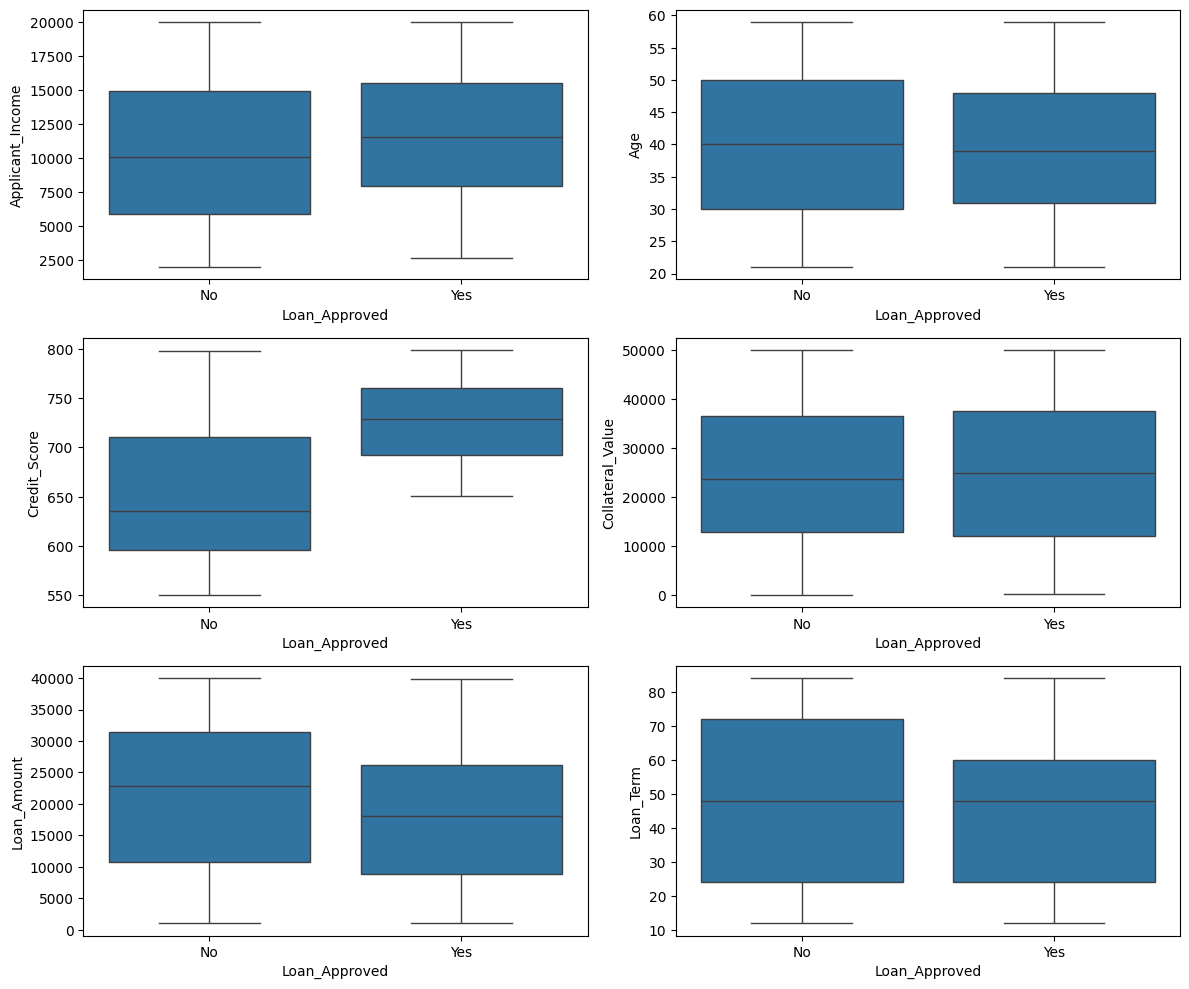

In [4]:
fig, axes = plt.subplots(3, 2, figsize=(12, 10))

sns.boxplot(ax=axes[0,0], data=df, x="Loan_Approved", y="Applicant_Income")
sns.boxplot(ax=axes[0,1], data=df, x="Loan_Approved", y="Age")

sns.boxplot(ax=axes[1,0], data=df, x="Loan_Approved", y="Credit_Score")
sns.boxplot(ax=axes[1,1], data=df, x="Loan_Approved", y="Collateral_Value")

sns.boxplot(ax=axes[2,0], data=df, x="Loan_Approved", y="Loan_Amount")
sns.boxplot(ax=axes[2,1], data=df, x="Loan_Approved", y="Loan_Term")

plt.tight_layout()
plt.show()

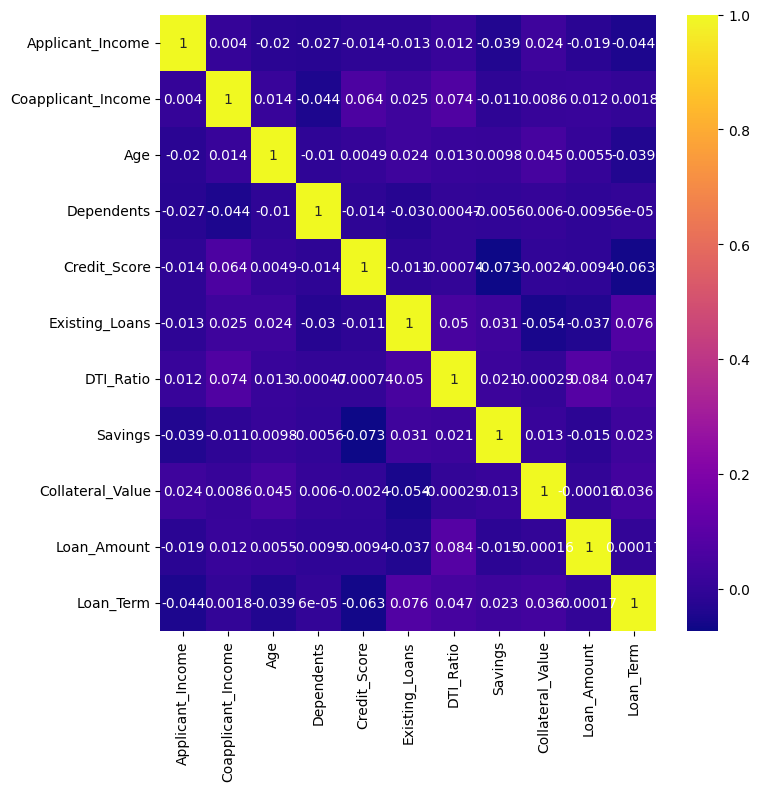

In [5]:
fig, axes = plt.subplots(1, 1, figsize=(8, 8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="plasma",
    ax=axes
)

plt.show()

In [6]:
df["Loan_Approved"] = df["Loan_Approved"].map({
    "No": 0,
    "Yes": 1
})

# Features
X = df.drop(columns=["Loan_Approved"])

# Target
y = df["Loan_Approved"]

print(X.head())
print(y.head())

   Applicant_Income  Coapplicant_Income Employment_Status   Age  \
0           17795.0              1387.0          Salaried  51.0   
1            2860.0              2679.0          Salaried  46.0   
2            7390.0              2106.0          Salaried  25.0   
3           13964.0              8173.0          Salaried  40.0   
4           13284.0              4223.0     Self-employed  31.0   

  Marital_Status  Dependents  Credit_Score  Existing_Loans  DTI_Ratio  \
0        Married         0.0         637.0             4.0       0.53   
1        Married         3.0         621.0             2.0       0.30   
2         Single         2.0         674.0             4.0       0.20   
3        Married         2.0         579.0             3.0       0.31   
4         Single         2.0         721.0             1.0       0.29   

   Savings  Collateral_Value  Loan_Amount  Loan_Term Loan_Purpose  \
0  19403.0           45638.0      16619.0       84.0     Personal   
1   2580.0          

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)

Train Shape: (760, 18)
Test Shape: (190, 18)


In [8]:
# Numeric columns
numeric_cols = X_train.select_dtypes(
    include=["int64", "float64"]
).columns

# Categorical columns
categorical_cols = X_train.select_dtypes(
    include=["object", "str"]
).columns

print("Numeric Columns:", numeric_cols)
print("Categorical Columns:", categorical_cols)

Numeric Columns: Index(['Applicant_Income', 'Coapplicant_Income', 'Age', 'Dependents',
       'Credit_Score', 'Existing_Loans', 'DTI_Ratio', 'Savings',
       'Collateral_Value', 'Loan_Amount', 'Loan_Term'],
      dtype='str')
Categorical Columns: Index(['Employment_Status', 'Marital_Status', 'Loan_Purpose', 'Property_Area',
       'Education_Level', 'Gender', 'Employer_Category'],
      dtype='str')


In [9]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        drop="first",
        handle_unknown="ignore"
    ))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_cols),
    ("cat", categorical_pipeline, categorical_cols)
])

In [10]:
print(y_train.unique())
print(y_train.dtype)

[1 0]
int64


In [17]:
pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000
    ))
])

params = {
    "model__C": [0.001, 0.01, 0.1, 1, 10, 100],

    "model__solver": [
        "lbfgs",
        "liblinear"
    ],

    "model__l1_ratio": [0],

    # "model__class_weight": [
    #     None,
    #     "balanced"
    # ]
}

clf = GridSearchCV(
    estimator=pipeline,
    param_grid=params,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    return_train_score=True
)

clf.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step..._iter=1000))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__C': [0.001, 0.01, ...], 'model__l1_ratio': [0], 'model__solver': ['lbfgs', 'liblinear']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- 

In [12]:
y_pred = clf.predict(X_test)
train_pred = clf.predict(X_train)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("Train Prediction", f1_score(y_train, train_pred))

Accuracy: 0.8894736842105263
Precision: 0.8545454545454545
Recall: 0.7833333333333333
F1 Score: 0.8173913043478261

Confusion Matrix:
[[122   8]
 [ 13  47]]

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.94      0.92       130
           1       0.85      0.78      0.82        60

    accuracy                           0.89       190
   macro avg       0.88      0.86      0.87       190
weighted avg       0.89      0.89      0.89       190

Train Prediction 0.8103448275862069


In [16]:
print("Best Parameters:")
print(clf.best_params_)

print("\nBest Estimator:")
print(clf.best_estimator_)

results = pd.DataFrame(clf.cv_results_)

print("\nCV Results:")
print(
    results[
        [
            "params",
            "mean_test_score",
            "rank_test_score"
        ]
    ].sort_values("rank_test_score")
)

Best Parameters:
{'model__C': 1, 'model__l1_ratio': 0, 'model__solver': 'lbfgs'}

Best Estimator:
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['Applicant_Income', 'Coapplicant_Income', 'Age', 'Dependents',
       'Credit_Score', 'Existing_Loans', 'DTI_Ratio', 'Savings',
       'Collateral_Value', 'Loan_Amount', 'Loan_Term'],
      dtype='str')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strate

In [19]:
import joblib

best_model = clf.best_estimator_

joblib.dump(
    best_model,
    "../backend/loan_model.pkl"
)

print("Model saved successfully")

Model saved successfully


In [21]:
model = joblib.load("../backend/loan_model.pkl")

print(model)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['Applicant_Income', 'Coapplicant_Income', 'Age', 'Dependents',
       'Credit_Score', 'Existing_Loans', 'DTI_Ratio', 'Savings',
       'Collateral_Value', 'Loan_Amount', 'Loan_Term'],
      dtype='str')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder'

In [ ]:
imputer = SimpleImputer(strategy="mean")

print(imputer.__dict__)

imputer.fit(X_train[numeric_cols])

print(imputer.__dict__)

{'missing_values': nan, 'add_indicator': False, 'keep_empty_features': False, 'strategy': 'mean', 'fill_value': None, 'copy': True}
{'missing_values': nan, 'add_indicator': False, 'keep_empty_features': False, 'strategy': 'mean', 'fill_value': None, 'copy': True, 'feature_names_in_': array(['Applicant_Income', 'Coapplicant_Income', 'Age', 'Dependents',
       'Credit_Score', 'Existing_Loans', 'DTI_Ratio', 'Savings',
       'Collateral_Value', 'Loan_Amount', 'Loan_Term'], dtype=object), 'n_features_in_': 11, '_fit_dtype': dtype('float64'), '_fill_dtype': dtype('float64'), 'indicator_': None, 'statistics_': array([1.08017147e+04, 5.09853417e+03, 4.00470914e+01, 1.47777778e+00,
       6.75033287e+02, 1.92659280e+00, 3.46611570e-01, 9.92409392e+03,
       2.45638705e+04, 2.05457175e+04, 4.81657459e+01])}


[1]
<class 'numpy.ndarray'>
1
<class 'numpy.int64'>
1
<class 'int'>
